In [1]:
import pandas as pd
from scipy.stats import kruskal

# 讀取 Excel 檔案
file_path = r"D:\IC LAB\Gait analysis\碩論相關\實驗結果\split6-9\最終結果.xlsx"
xls = pd.ExcelFile(file_path)

# 讀取 '演算法' 工作表
df_alg = xls.parse("演算法")

# 將資料依照演算法分組
grouped = df_alg.groupby('Alg.')

# 提取 Cluster 0 / Cluster 1 的準確率資料
cluster0_data = [group['Cluster 0_ACC'].values for _, group in grouped]
cluster1_data = [group['Cluster 1_ACC'].values for _, group in grouped]
algorithm_names = list(grouped.groups.keys())

# Kruskal–Wallis H test
stat0, pval0 = kruskal(*cluster0_data)
stat1, pval1 = kruskal(*cluster1_data)

print("=== Kruskal–Wallis H 檢定結果 ===")
print(f"Cluster 0: H-statistic = {stat0:.4f}, p-value = {pval0:.4f}")
print(f"Cluster 1: H-statistic = {stat1:.4f}, p-value = {pval1:.4f}")


=== Kruskal–Wallis H 檢定結果 ===
Cluster 0: H-statistic = 21.1997, p-value = 0.0001
Cluster 1: H-statistic = 40.0924, p-value = 0.0000


In [3]:
import pandas as pd
from scipy.stats import kruskal
import scikit_posthocs as sp

# 讀取資料
file_path = r"D:\IC LAB\Gait analysis\碩論相關\實驗結果\split6-9\最終結果.xlsx"
xls = pd.ExcelFile(file_path)
df_alg = xls.parse("演算法")

# Dunn’s test for Cluster 0
df0 = df_alg[['Alg.', 'Cluster 0_ACC']].rename(columns={'Alg.': 'group', 'Cluster 0_ACC': 'value'})
dunn_result_0 = sp.posthoc_dunn(df0, val_col='value', group_col='group', p_adjust='bonferroni')

# Dunn’s test for Cluster 1
df1 = df_alg[['Alg.', 'Cluster 1_ACC']].rename(columns={'Alg.': 'group', 'Cluster 1_ACC': 'value'})
dunn_result_1 = sp.posthoc_dunn(df1, val_col='value', group_col='group', p_adjust='bonferroni')

# 輸出結果
print("=== Cluster 0 Dunn’s Test (Bonferroni corrected) ===")
print(dunn_result_0)

print("\n=== Cluster 1 Dunn’s Test (Bonferroni corrected) ===")
print(dunn_result_1)


=== Cluster 0 Dunn’s Test (Bonferroni corrected) ===
          GA       PSO       SSO       初始解
GA   1.00000  1.000000  0.000220  1.000000
PSO  1.00000  1.000000  0.000954  1.000000
SSO  0.00022  0.000954  1.000000  0.014041
初始解  1.00000  1.000000  0.014041  1.000000

=== Cluster 1 Dunn’s Test (Bonferroni corrected) ===
           GA       PSO           SSO           初始解
GA   1.000000  1.000000  4.060406e-03  2.204948e-02
PSO  1.000000  1.000000  1.498184e-03  4.958792e-02
SSO  0.004060  0.001498  1.000000e+00  1.744498e-09
初始解  0.022049  0.049588  1.744498e-09  1.000000e+00


In [1]:
import pandas as pd
from scipy.stats import kruskal

# 讀取 Excel 檔案與修正工作表
file_path = r"D:\IC LAB\Gait analysis\碩論相關\實驗結果\split6-9\最終結果.xlsx"
df = pd.read_excel(file_path, sheet_name='修正')

# 準備 Cluster 0 的資料
cluster0_df = df[['model', 'Cluster 0_ACC']].dropna()

# 將每組 model 的準確率整理成 dictionary
model_groups = cluster0_df.groupby('model')['Cluster 0_ACC'].apply(list).to_dict()

# 提取模型名稱與資料
models = list(model_groups.keys())
data_lists = [model_groups[model] for model in models]

# 執行 Kruskal–Wallis H test
h_stat, p_val = kruskal(*data_lists)

# 顯示結果
print("=== Kruskal–Wallis H test for Cluster 0_ACC ===")
print(f"H-statistic: {h_stat:.4f}")
print(f"p-value    : {p_val:.4f}")


=== Kruskal–Wallis H test for Cluster 0_ACC ===
H-statistic: 85.0019
p-value    : 0.0000



=== Dunn’s test with Bonferroni correction (Cluster 0_ACC) ===
               SSO-ST-GCN*  SSO-ST-GCN++       ST-GCN*      ST-GCN++
SSO-ST-GCN*   1.000000e+00  6.452711e-01  3.371220e-09  2.493661e-12
SSO-ST-GCN++  6.452711e-01  1.000000e+00  4.129006e-08  5.605258e-11
ST-GCN*       3.371220e-09  4.129006e-08  1.000000e+00  5.307906e-01
ST-GCN++      2.493661e-12  5.605258e-11  5.307906e-01  1.000000e+00


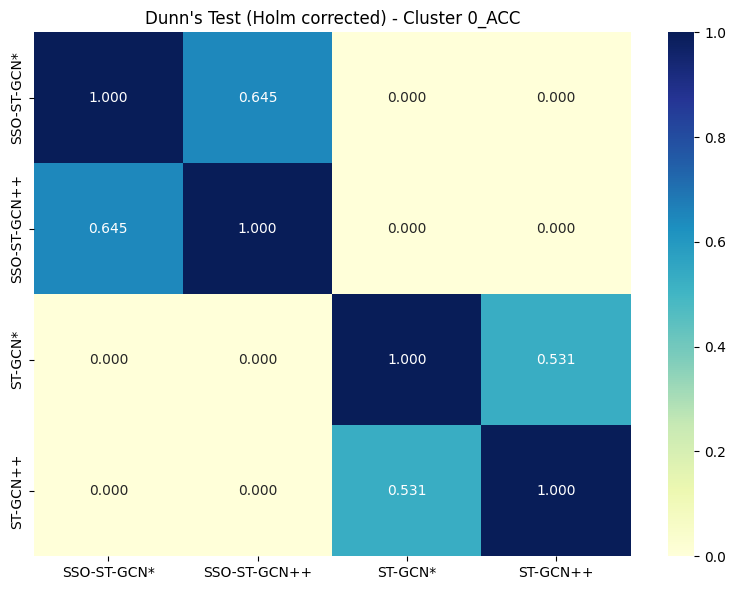

In [2]:
import scikit_posthocs as sp
import seaborn as sns
import matplotlib.pyplot as plt

# 重新命名欄位讓 Dunn’s test 能識別
dunn_df = cluster0_df.rename(columns={
    'model': 'group',
    'Cluster 0_ACC': 'value'
})

# 執行 Dunn’s test 並進行 Bonferroni 校正
# dunn_result = sp.posthoc_dunn(dunn_df, val_col='value', group_col='group', p_adjust='bonferroni')
dunn_result = sp.posthoc_dunn(dunn_df, val_col='value', group_col='group', p_adjust='holm')
# 顯示結果
print("\n=== Dunn’s test with Bonferroni correction (Cluster 0_ACC) ===")
print(dunn_result)

# （可選）畫出熱力圖
plt.figure(figsize=(8, 6))
sns.heatmap(dunn_result, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("Dunn's Test (Holm corrected) - Cluster 0_ACC")
plt.tight_layout()
plt.show()


In [3]:
import pandas as pd
from scipy.stats import kruskal

# 讀取 Excel 檔案與修正工作表
file_path = r"D:\IC LAB\Gait analysis\碩論相關\實驗結果\split6-9\最終結果.xlsx"
df = pd.read_excel(file_path, sheet_name='修正')

# 準備 Cluster 0 的資料
cluster1_df = df[['model', 'Cluster 1_ACC']].dropna()

# 將每組 model 的準確率整理成 dictionary
model_groups = cluster1_df.groupby('model')['Cluster 1_ACC'].apply(list).to_dict()

# 提取模型名稱與資料
models = list(model_groups.keys())
data_lists = [model_groups[model] for model in models]

# 執行 Kruskal–Wallis H test
h_stat, p_val = kruskal(*data_lists)

# 顯示結果
print("=== Kruskal–Wallis H test for Cluster 1_ACC ===")
print(f"H-statistic: {h_stat:.4f}")
print(f"p-value    : {p_val:.4f}")


=== Kruskal–Wallis H test for Cluster 1_ACC ===
H-statistic: 82.1902
p-value    : 0.0000



=== Dunn’s test with Bonferroni correction (Cluster 1_ACC) ===
               SSO-ST-GCN*  SSO-ST-GCN++       ST-GCN*      ST-GCN++
SSO-ST-GCN*   1.000000e+00  1.401612e-03  1.176776e-08  1.897830e-17
SSO-ST-GCN++  1.401612e-03  1.000000e+00  1.342005e-02  7.694648e-07
ST-GCN*       1.176776e-08  1.342005e-02  1.000000e+00  1.250855e-02
ST-GCN++      1.897830e-17  7.694648e-07  1.250855e-02  1.000000e+00


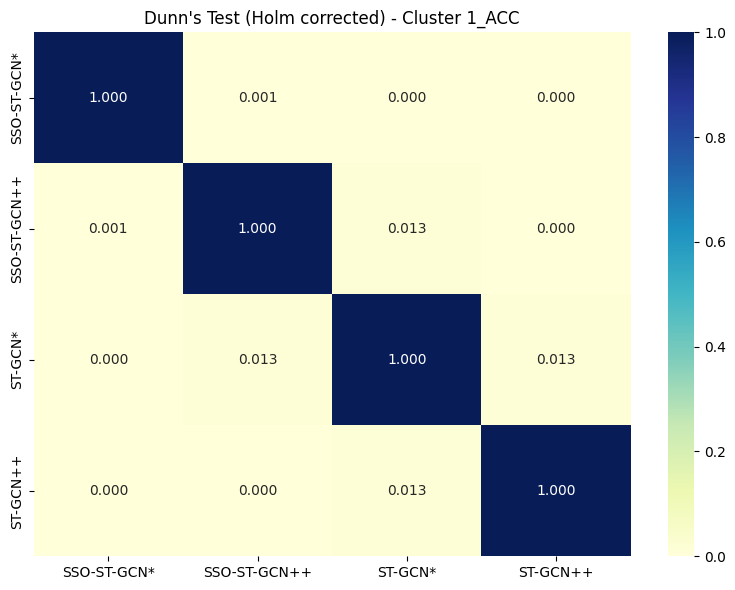

In [4]:
import scikit_posthocs as sp
import seaborn as sns
import matplotlib.pyplot as plt

# 重新命名欄位讓 Dunn’s test 能識別
dunn_df = cluster1_df.rename(columns={
    'model': 'group',
    'Cluster 1_ACC': 'value'
})

# 執行 Dunn’s test 並進行 Bonferroni 校正
#dunn_result = sp.posthoc_dunn(dunn_df, val_col='value', group_col='group', p_adjust='bonferroni')
dunn_result = sp.posthoc_dunn(dunn_df, val_col='value', group_col='group', p_adjust='holm')
# 顯示結果
print("\n=== Dunn’s test with Bonferroni correction (Cluster 1_ACC) ===")
print(dunn_result)

# （可選）畫出熱力圖
plt.figure(figsize=(8, 6))
sns.heatmap(dunn_result, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("Dunn's Test (Holm corrected) - Cluster 1_ACC")
plt.tight_layout()
plt.show()


In [9]:
summary_stats = {
    model: {
        'mean': round(pd.Series(scores).mean(), 6),
        'median': round(pd.Series(scores).median(), 6)
    }
    for model, scores in model_groups.items()
}

# 整理成 DataFrame 顯示
summary_df = pd.DataFrame.from_dict(summary_stats, orient='index').reset_index()
summary_df.columns = ['Model', 'Mean Accuracy', 'Median Accuracy']
print(summary_df)

          Model  Mean Accuracy  Median Accuracy
0   SSO-ST-GCN*       0.770347         0.770833
1  SSO-ST-GCN++       0.760370         0.761458
2       ST-GCN*       0.749954         0.749306
3      ST-GCN++       0.733495         0.739583


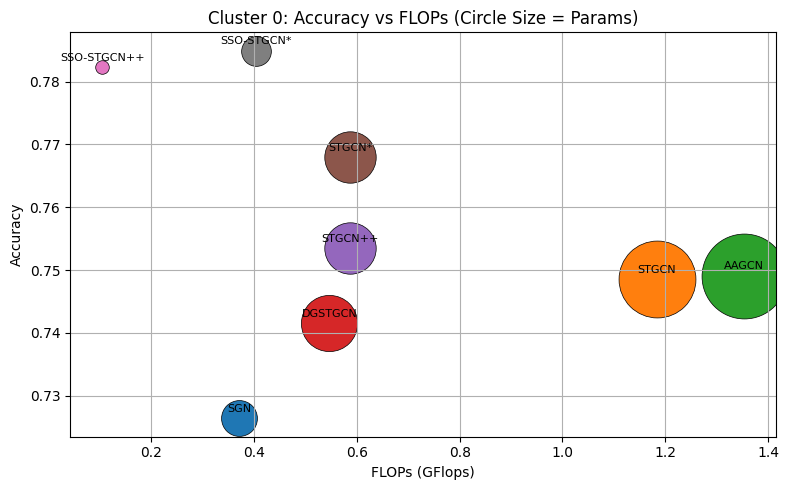

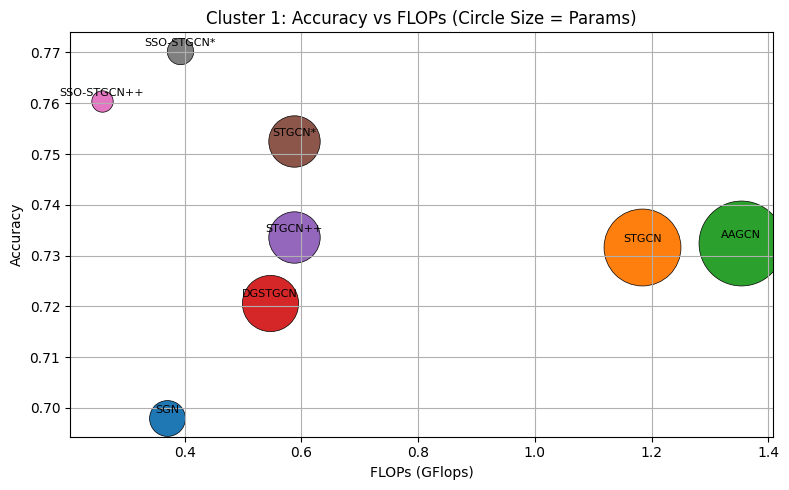

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

# 建立資料
data = {
    "Model": ["SGN", "STGCN", "AAGCN", "DGSTGCN", "STGCN++", "STGCN*", "SSO-STGCN++", "SSO-STGCN*"] * 2,
    "Cluster": ["Cluster 0"] * 8 + ["Cluster 1"] * 8,
    "Accuracy": [0.726389, 0.748519, 0.749097, 0.741551, 0.753495, 0.767917, 0.782338, 0.784907,
                 0.697940, 0.731690, 0.732454, 0.720741, 0.733565, 0.752500, 0.760370, 0.770347],
    "FLOPs": [0.370462, 1.183615, 1.353584, 0.546565, 0.587210, 0.587210, 0.104258, 0.404276,
              0.370462, 1.183615, 1.353584, 0.546565, 0.587210, 0.587210, 0.258450, 0.392651],
    "Params": [0.665740, 3.065416, 3.736668, 1.637932, 1.369664, 1.369664, 0.095780, 0.457676,
               0.665740, 3.065416, 3.736668, 1.637932, 1.369664, 1.369664, 0.237436, 0.360742]
}

df = pd.DataFrame(data)

# 指定每個模型的顏色
model_colors = {
    "SGN": "tab:blue",
    "STGCN": "tab:orange",
    "AAGCN": "tab:green",
    "DGSTGCN": "tab:red",
    "STGCN++": "tab:purple",
    "STGCN*": "tab:brown",
    "SSO-STGCN++": "tab:pink",
    "SSO-STGCN*": "tab:gray"
}

# 分群資料
cluster_0 = df[df["Cluster"] == "Cluster 0"]
cluster_1 = df[df["Cluster"] == "Cluster 1"]

# 畫圖：Cluster 0（實心圓 + 彩色）
fig, ax = plt.subplots(figsize=(8, 5))
for _, row in cluster_0.iterrows():
    ax.scatter(row["FLOPs"], row["Accuracy"],
               s=row["Params"] * 1000,
               color=model_colors[row["Model"]],
               edgecolors='black',
               linewidths=0.5)
    ax.text(row["FLOPs"], row["Accuracy"] + 0.001, row["Model"], fontsize=8, ha='center')
ax.set_xlabel("FLOPs (GFlops)")
ax.set_ylabel("Accuracy")
ax.set_title("Cluster 0: Accuracy vs FLOPs (Circle Size = Params)")
plt.grid(True)
plt.tight_layout()
plt.show()

# 畫圖：Cluster 1（實心圓 + 彩色）
fig, ax = plt.subplots(figsize=(8, 5))
for _, row in cluster_1.iterrows():
    ax.scatter(row["FLOPs"], row["Accuracy"],
               s=row["Params"] * 1000,
               color=model_colors[row["Model"]],
               edgecolors='black',
               linewidths=0.5)
    ax.text(row["FLOPs"], row["Accuracy"] + 0.001, row["Model"], fontsize=8, ha='center')
ax.set_xlabel("FLOPs (GFlops)")
ax.set_ylabel("Accuracy")
ax.set_title("Cluster 1: Accuracy vs FLOPs (Circle Size = Params)")
plt.grid(True)
plt.tight_layout()
plt.show()

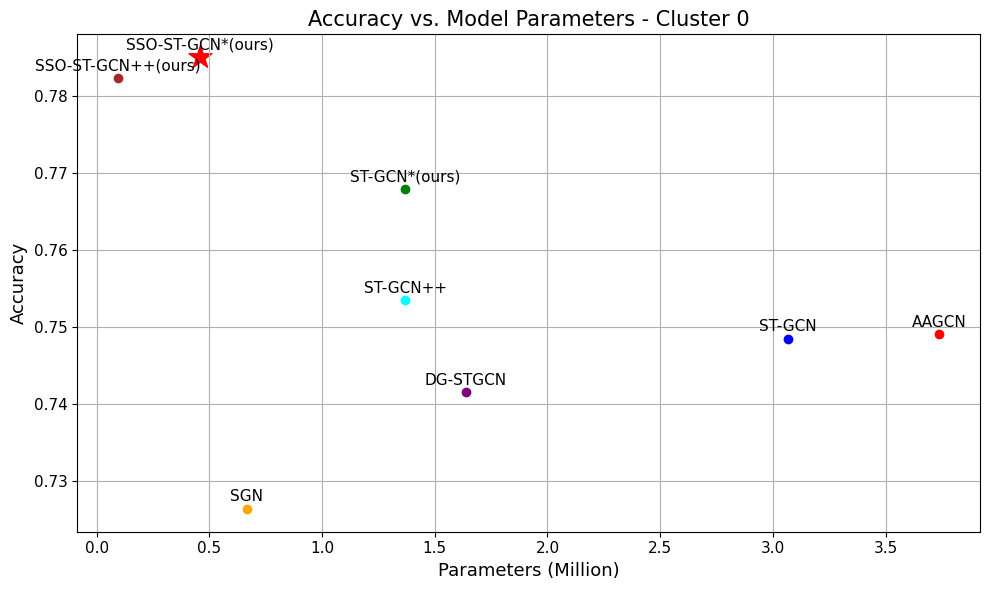

In [3]:
# 重新載入必要模組
import pandas as pd
import matplotlib.pyplot as plt

# 重新建立模型資料
model_data = {
    'Model': [
        'SGN', 'ST-GCN', 'AAGCN', 'DG-STGCN', 'ST-GCN++',
        'ST-GCN*(ours)', 'SSO-ST-GCN++(ours)', 'SSO-ST-GCN*(ours)'
    ],
    'Accuracy': [
        0.726389, 0.748519, 0.749097, 0.741551, 0.753495,
        0.767917, 0.782338, 0.785116
    ],
    'Params': [
        0.66574, 3.065416, 3.736668, 1.637932, 1.369664,
        1.369664, 0.09578, 0.457676
    ]
}

# 建立 DataFrame
plot_df = pd.DataFrame(model_data)
# 指定不同顏色以區分模型
colors = [
    'orange', 'blue', 'red', 'purple', 'cyan',
    'green', 'brown', 'black'
]

# 繪圖
plt.figure(figsize=(10, 6))
for idx, row in plot_df.iterrows():
    if row['Model'] == 'SSO-ST-GCN*(ours)':
        plt.scatter(row['Params'], row['Accuracy'], color='red', marker='*', s=300, label=row['Model'])
    else:
        plt.scatter(row['Params'], row['Accuracy'], color=colors[idx], label=row['Model'])

# 加上標籤（字體放大）
for idx, row in plot_df.iterrows():
    plt.text(row['Params'], row['Accuracy'] + 0.001, row['Model'], fontsize=11, ha='center')

# 圖表設定
plt.xlabel('Parameters (Million)', fontsize=13)
plt.ylabel('Accuracy', fontsize=13)
plt.title('Accuracy vs. Model Parameters - Cluster 0', fontsize=15)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.grid(True)
plt.tight_layout()
plt.show()

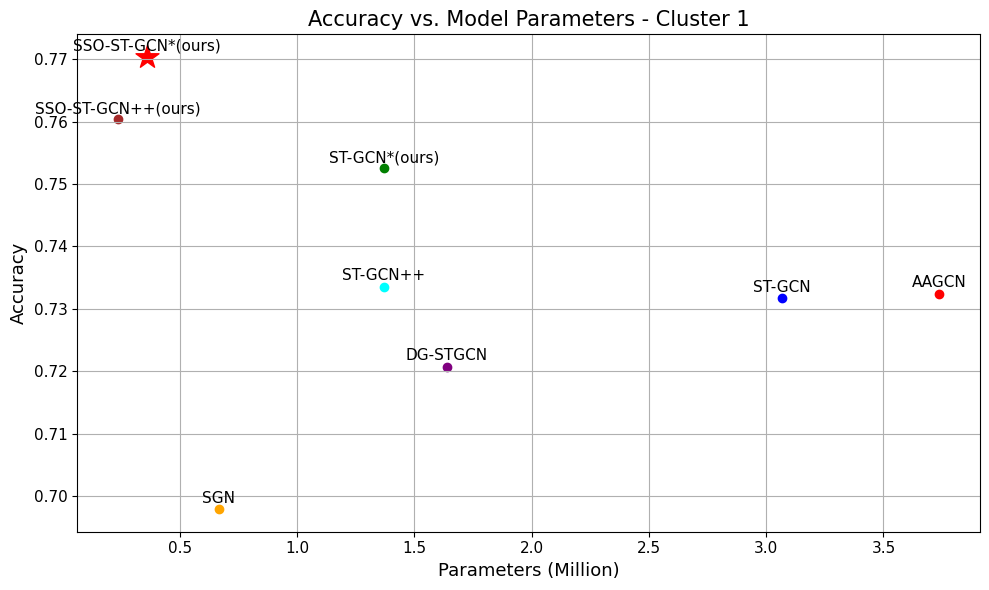

In [16]:
# 重新載入必要模組
import pandas as pd
import matplotlib.pyplot as plt

# 重新建立模型資料
model_data = {
    'Model': [
        'SGN', 'ST-GCN', 'AAGCN', 'DG-STGCN', 'ST-GCN++',
        'ST-GCN*(ours)', 'SSO-ST-GCN++(ours)', 'SSO-ST-GCN*(ours)'
    ],
    'Accuracy': [
        0.697940, 0.731690, 0.732454, 0.720741, 0.733565,
        0.752500, 0.760370, 0.770347
    ],
    'Params': [
        0.665740, 3.065416, 3.736668, 1.637932, 1.369664,
        1.369664, 0.237436, 0.360742
    ]
}

# 建立 DataFrame
plot_df = pd.DataFrame(model_data)
# 指定不同顏色以區分模型
colors = [
    'orange', 'blue', 'red', 'purple', 'cyan',
    'green', 'brown', 'black'
]

# 繪圖
plt.figure(figsize=(10, 6))
for idx, row in plot_df.iterrows():
    if row['Model'] == 'SSO-ST-GCN*(ours)':
        plt.scatter(row['Params'], row['Accuracy'], color='red', marker='*', s=300, label=row['Model'])
    else:
        plt.scatter(row['Params'], row['Accuracy'], color=colors[idx], label=row['Model'])

# 加上標籤（字體放大）
for idx, row in plot_df.iterrows():
    plt.text(row['Params'], row['Accuracy'] + 0.001, row['Model'], fontsize=11, ha='center')

# 圖表設定
plt.xlabel('Parameters (Million)', fontsize=13)
plt.ylabel('Accuracy', fontsize=13)
plt.title('Accuracy vs. Model Parameters - Cluster 1', fontsize=15)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.grid(True)
plt.tight_layout()
plt.show()

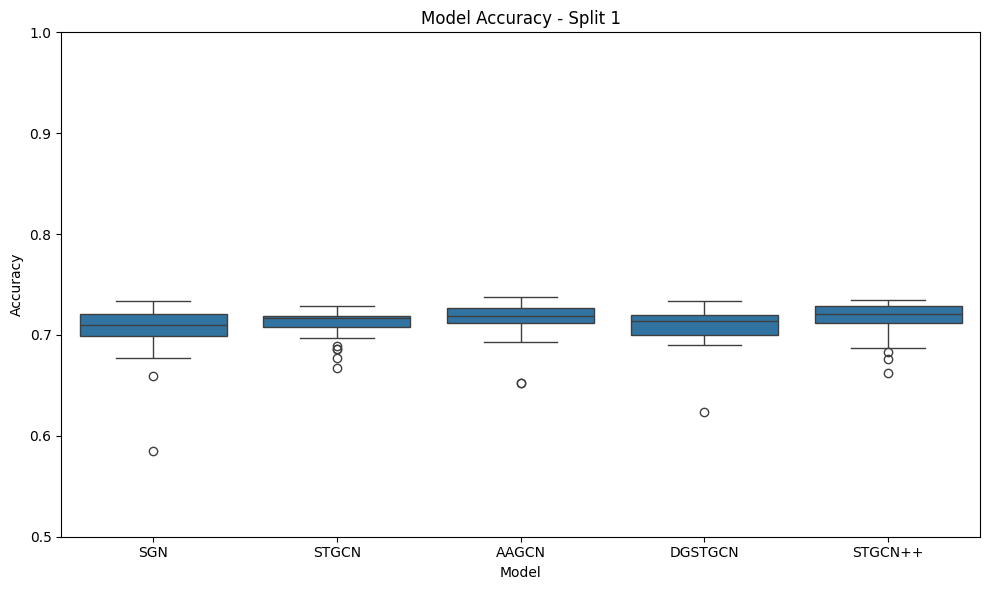

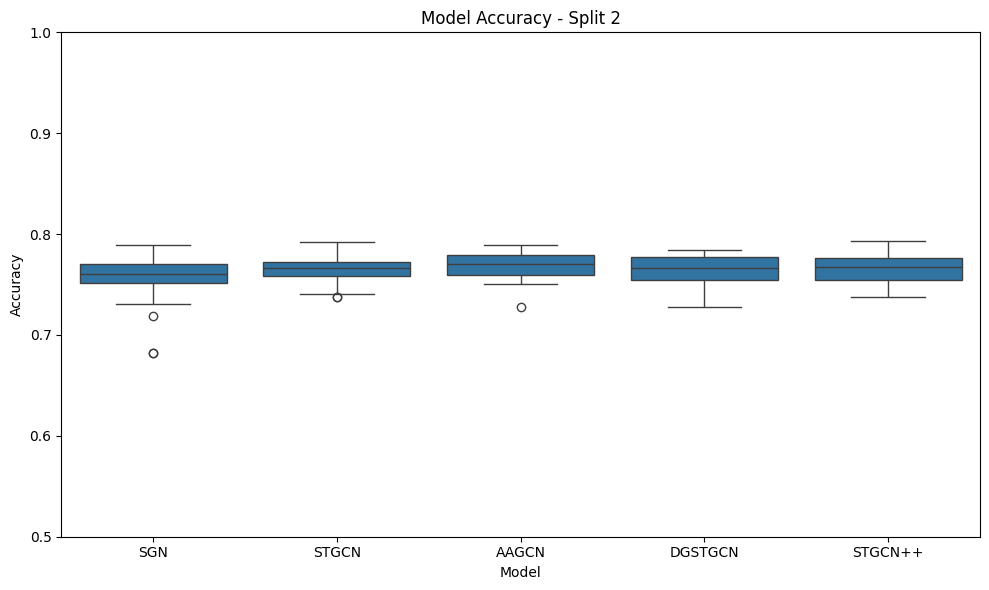

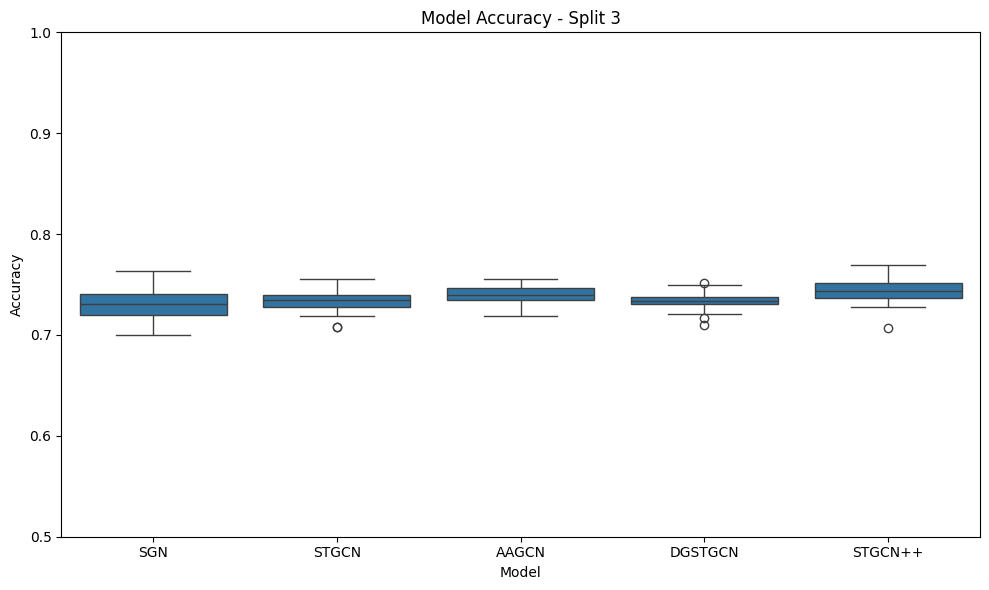

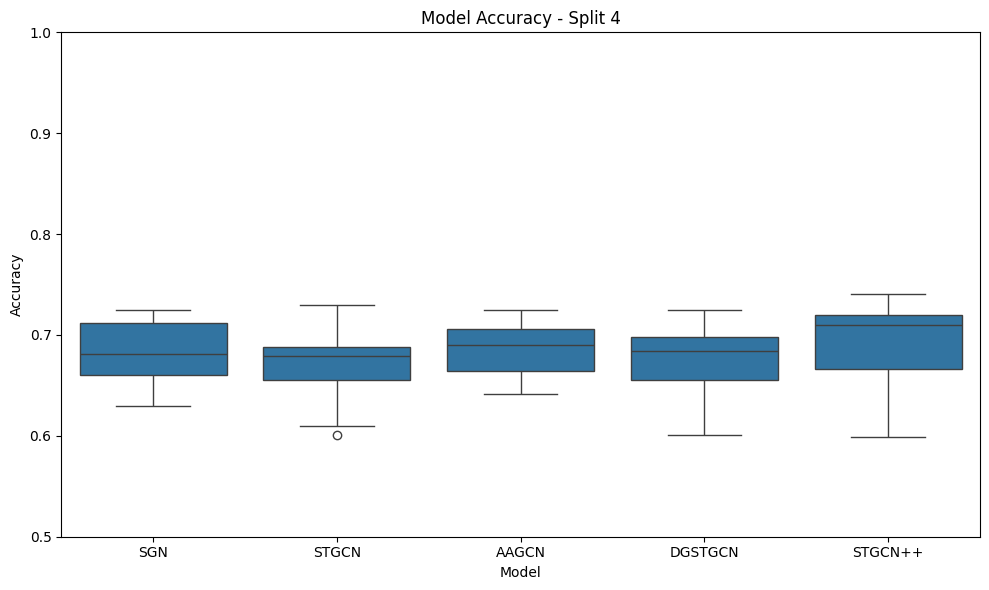

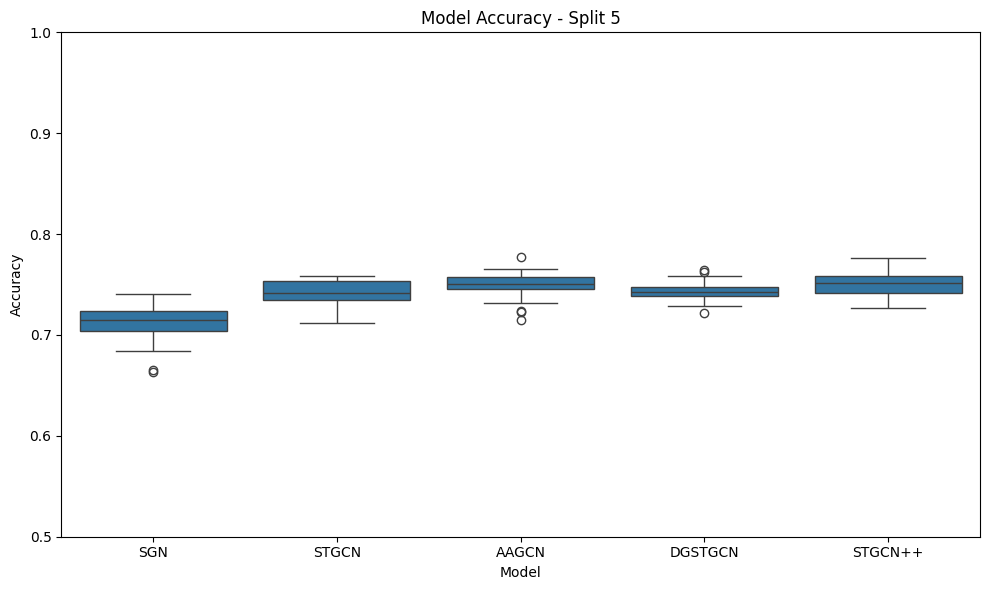

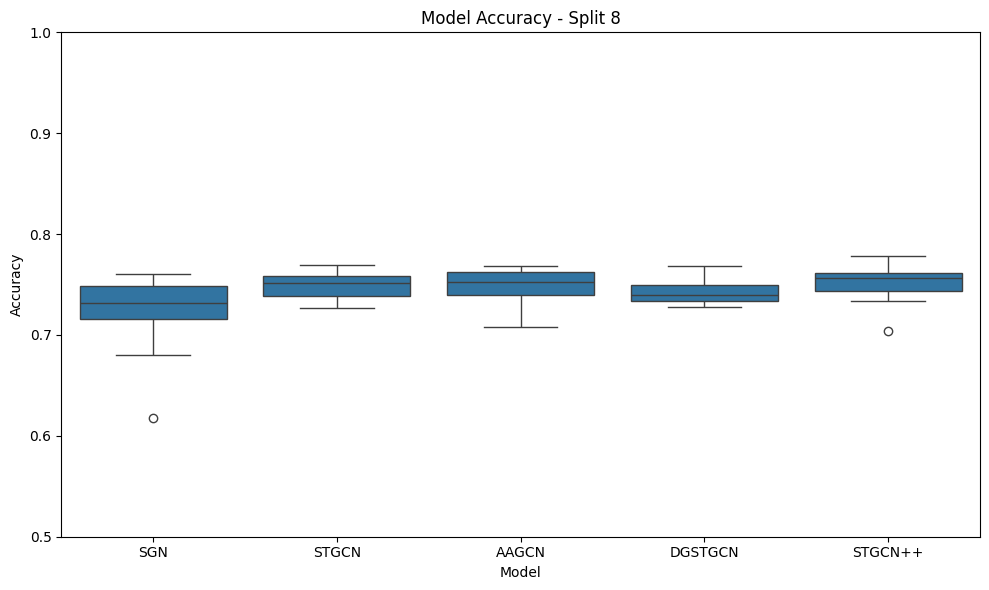

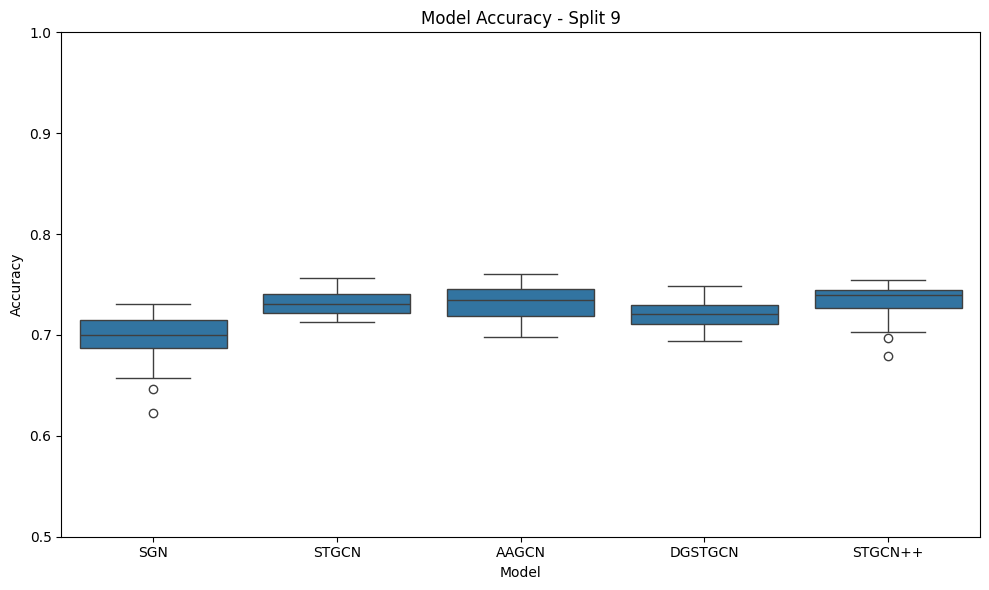

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 載入 Excel 檔案
xls = pd.ExcelFile(r"D:\IC LAB\Gait analysis\碩論相關\實驗結果\最終結果.xlsx")

# 為每個分頁繪圖
for sheet_name in xls.sheet_names:
    df = xls.parse(sheet_name)

    # 將資料轉為長格式
    df_melted = df.melt(var_name='Model', value_name='Accuracy')

    # 繪製盒鬚圖
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_melted, x='Model', y='Accuracy')
    plt.ylim(0.5, 1.0)
    plt.title(f'Model Accuracy - Split {sheet_name}')
    plt.ylabel('Accuracy')
    plt.xlabel('Model')
    plt.tight_layout()
    plt.show()


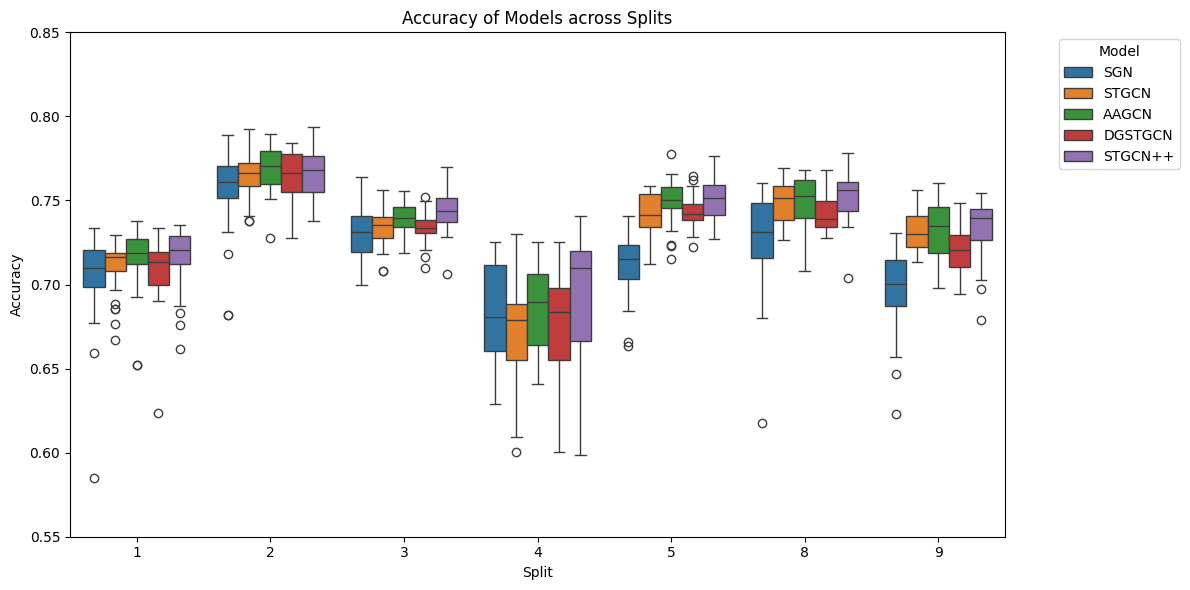

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 載入 Excel 檔案
xls = pd.ExcelFile(r"D:\IC LAB\Gait analysis\碩論相關\實驗結果\最終結果.xlsx")

# 合併所有分頁資料，加上 Split 欄位
df_all = []

for sheet_name in xls.sheet_names:
    df = xls.parse(sheet_name)
    df_melted = df.melt(var_name="Model", value_name="Accuracy")
    df_melted["Split"] = sheet_name
    df_all.append(df_melted)

# 合併成一個 DataFrame
df_all = pd.concat(df_all, ignore_index=True)

# 以 Split 為 x 軸繪製盒鬚圖，每個模型用不同顏色表示
plt.figure(figsize=(12, 6))
# sns.boxplot(data=df_all, x="Split", y="Accuracy", hue="Model", showfliers=False)
sns.boxplot(data=df_all, x="Split", y="Accuracy", hue="Model")
plt.title("Accuracy of Models across Splits")
plt.ylabel("Accuracy")
plt.xlabel("Split")
plt.ylim(0.55, 0.85)
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [12]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
import pandas as pd
# 載入資料
# train = np.load(r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\data\drunk71_small\dataset_yolo_sagittal_split8_90frames_j_4class_train.npz")
# val = np.load(r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\data\drunk71_small\dataset_yolo_sagittal_split8_90frames_j_4class_val.npz")
# test = np.load(r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\data\drunk71_small\dataset_yolo_sagittal_split8_90frames_j_4class_test.npz")

# Augmentation 設定
flip_pairs = [(1, 2), (3, 4), (5, 6), (7, 8), (9, 10), (11, 12), (13, 14), (15, 16)]
augment_windows = [(0, 63), (13, 76), (26, 89)]  # 確保 64 frames 的片段

# 特徵提取函數
def extract_handcrafted_features(kp):
    kp = kp[0]  # (T, V, C)
    velocity = np.diff(kp[..., :2], axis=0)
    acceleration = np.diff(velocity, axis=0)
    vel_mean = velocity.mean(axis=0).flatten()
    acc_mean = acceleration.mean(axis=0).flatten()
    symmetry = [np.abs(kp[:, a, 0] - (1 - kp[:, b, 0])).mean() for a, b in flip_pairs]
    return np.concatenate([vel_mean, acc_mean, symmetry])

# 處理資料：augmentation + flip + 特徵
def process_data(npz_path):
    data = np.load(npz_path)
    keypoints = data["keypoints"]
    labels = data["labels"]
    names = data["names"]
    X, y = [], []

    for i in range(len(keypoints)):
        kp = keypoints[i]  # (M, T, V, C)
        label = labels[i]
        orig_T = kp.shape[1]

        # 類別0：做三段式裁剪
        if label == 0:
            for start, end in augment_windows:
                if end + 1 <= orig_T:
                    new_kp = kp[:, start:end + 1]  # (M, 64, V, C)
                    feats = extract_handcrafted_features(new_kp)
                    X.append(feats)
                    y.append(label)

        # 原始樣本
        feats = extract_handcrafted_features(kp[:, :64])  # 前64帧
        X.append(feats)
        y.append(label)

    # flip augmentation
    flipped_X, flipped_y = [], []
    for i in range(len(keypoints)):
        kp = keypoints[i][:, :64].copy()
        kp[..., 0] = 1 - kp[..., 0]
        for a, b in flip_pairs:
            kp[..., [a, b], :] = kp[..., [b, a], :]
        feats = extract_handcrafted_features(kp)
        flipped_X.append(feats)
        flipped_y.append(labels[i])

    # 合併原始與翻轉
    X.extend(flipped_X)
    y.extend(flipped_y)

    return np.array(X), np.array(y)

# 載入與處理資料
train_path = r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\data\drunk71_small\dataset_yolo_sagittal_split8_90frames_j_4class_train.npz"
val_path = r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\data\drunk71_small\dataset_yolo_sagittal_split8_90frames_j_4class_val.npz"
test_path = r"D:\pythonProject\IC Lab\Gait_analysis\pyskl\data\drunk71_small\dataset_yolo_sagittal_split8_90frames_j_4class_test.npz"

X_train1, y_train1 = process_data(train_path)
X_val, y_val = process_data(val_path)
X_test, y_test = process_data(test_path)

X_train = np.concatenate([X_train1, X_val], axis=0)
y_train = np.concatenate([y_train1, y_val], axis=0)

# 訓練 KNN 並預測
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

# 顯示分類報告
report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

# 報告
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.69      0.70       600
           1       0.24      0.26      0.25       240
           2       0.25      0.26      0.26       240
           3       0.34      0.33      0.33       240

    accuracy                           0.47      1320
   macro avg       0.39      0.38      0.38      1320
weighted avg       0.47      0.47      0.47      1320



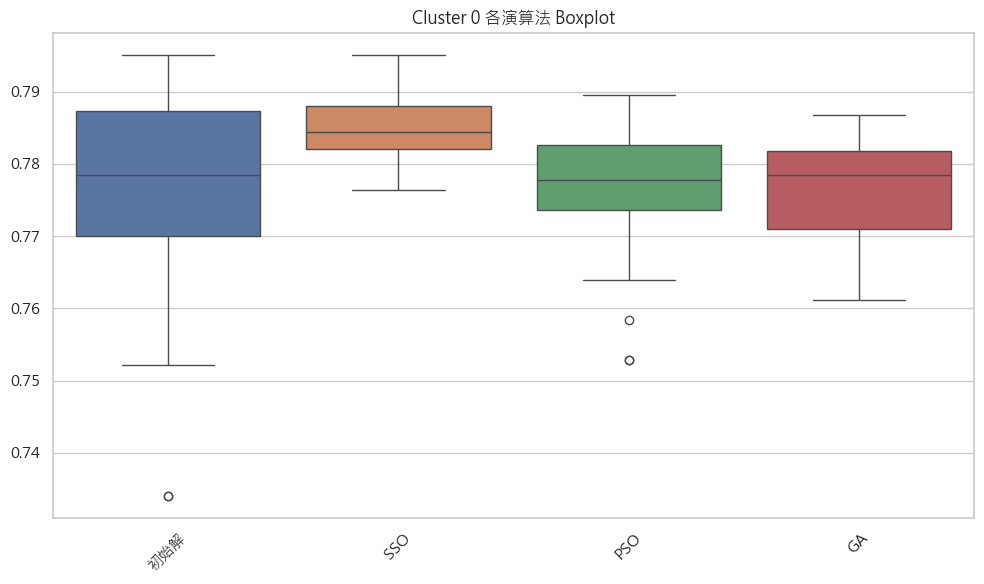

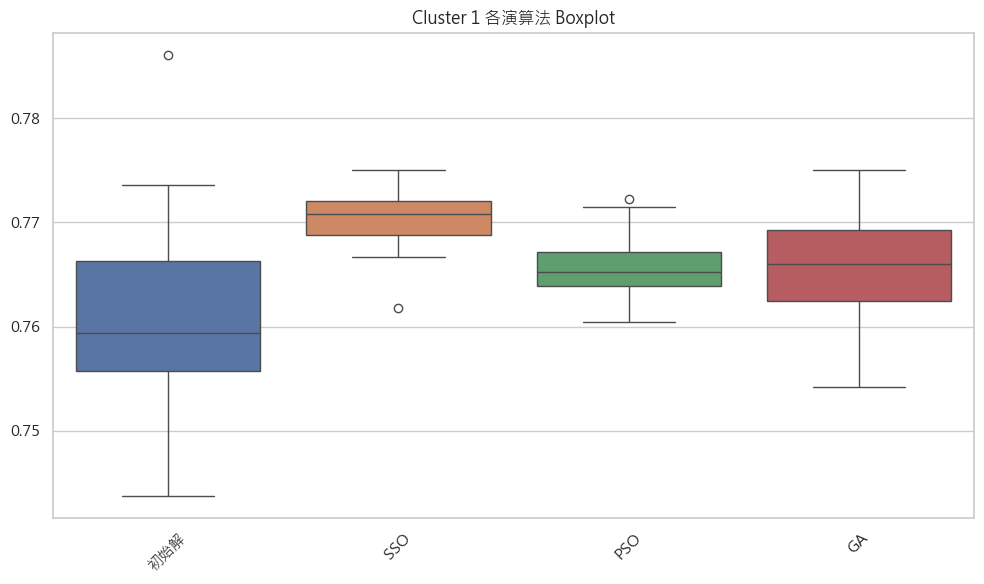

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

# 設定可顯示中文的字型（依作業系統調整）
matplotlib.rcParams['font.family'] = 'Microsoft JhengHei'  # Windows 使用者
# matplotlib.rcParams['font.family'] = 'PingFang TC'  # macOS 使用者
# matplotlib.rcParams['font.family'] = 'SimHei'  # 中文 Linux 常用字型
matplotlib.rcParams['axes.unicode_minus'] = False

# 載入 Excel 檔案
file_path = r"C:\Users\User\OneDrive\桌面\claude畫圖.xlsx"  # 檔案名稱或完整路徑
xls = pd.ExcelFile(file_path)


# 讀取兩個工作表
df_cluster_0 = pd.read_excel(xls, sheet_name='Cluster 0')
df_cluster_1 = pd.read_excel(xls, sheet_name='Cluster 1')

# 繪製 Cluster 0 的 boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_cluster_0)
plt.title('Cluster 0 各演算法 Boxplot')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 繪製 Cluster 1 的 boxplot
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_cluster_1)
plt.title('Cluster 1 各演算法 Boxplot')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [5]:
import pandas as pd
from scipy.stats import kruskal

# 讀取 Excel 檔案與修正工作表
file_path = r"D:\IC LAB\Gait analysis\碩論相關\實驗結果\split6-9\最終結果.xlsx"
df = pd.read_excel(file_path, sheet_name='F1')

# 準備 Cluster 0 的資料
cluster0_df = df[['model', 'Cluster 0_F1']].dropna()

# 將每組 model 的準確率整理成 dictionary
model_groups = cluster0_df.groupby('model')['Cluster 0_F1'].apply(list).to_dict()

# 提取模型名稱與資料
models = list(model_groups.keys())
data_lists = [model_groups[model] for model in models]

# 執行 Kruskal–Wallis H test
h_stat, p_val = kruskal(*data_lists)

# 顯示結果
print("=== Kruskal–Wallis H test for Cluster 0_F1 ===")
print(f"H-statistic: {h_stat:.4f}")
print(f"p-value    : {p_val:.4f}")


=== Kruskal–Wallis H test for Cluster 0_F1 ===
H-statistic: 58.9287
p-value    : 0.0000



=== Dunn’s test with Bonferroni correction (Cluster 0_F1) ===
               SSO-ST-GCN*  SSO-ST-GCN++   ST-GCN*      ST-GCN++
SSO-ST-GCN*   1.000000e+00  3.271869e-01  0.000006  2.194412e-10
SSO-ST-GCN++  3.271869e-01  1.000000e+00  0.000356  8.624940e-08
ST-GCN*       5.503612e-06  3.562855e-04  1.000000  1.472716e-01
ST-GCN++      2.194412e-10  8.624940e-08  0.147272  1.000000e+00


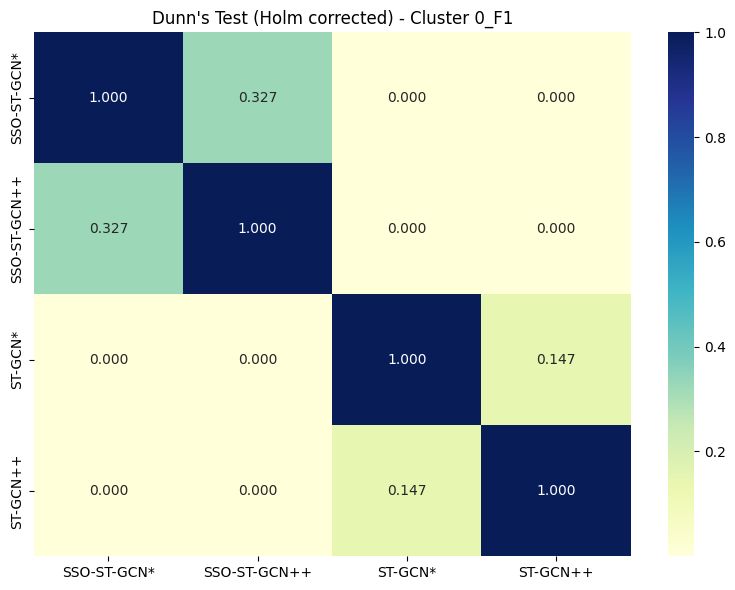

In [6]:
import scikit_posthocs as sp
import seaborn as sns
import matplotlib.pyplot as plt

# 重新命名欄位讓 Dunn’s test 能識別
dunn_df = cluster0_df.rename(columns={
    'model': 'group',
    'Cluster 0_F1': 'value'
})

# 執行 Dunn’s test 並進行 Bonferroni 校正
#dunn_result = sp.posthoc_dunn(dunn_df, val_col='value', group_col='group', p_adjust='bonferroni')
dunn_result = sp.posthoc_dunn(dunn_df, val_col='value', group_col='group', p_adjust='holm')
# 顯示結果
print("\n=== Dunn’s test with Bonferroni correction (Cluster 0_F1) ===")
print(dunn_result)

# （可選）畫出熱力圖
plt.figure(figsize=(8, 6))
sns.heatmap(dunn_result, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("Dunn's Test (Holm corrected) - Cluster 0_F1")
plt.tight_layout()
plt.show()


In [7]:
import pandas as pd
from scipy.stats import kruskal

# 讀取 Excel 檔案與修正工作表
file_path = r"D:\IC LAB\Gait analysis\碩論相關\實驗結果\split6-9\最終結果.xlsx"
df = pd.read_excel(file_path, sheet_name='F1')

# 準備 Cluster 0 的資料
cluster0_df = df[['model', 'Cluster 1_F1']].dropna()

# 將每組 model 的準確率整理成 dictionary
model_groups = cluster0_df.groupby('model')['Cluster 1_F1'].apply(list).to_dict()

# 提取模型名稱與資料
models = list(model_groups.keys())
data_lists = [model_groups[model] for model in models]

# 執行 Kruskal–Wallis H test
h_stat, p_val = kruskal(*data_lists)

# 顯示結果
print("=== Kruskal–Wallis H test for Cluster 1_F1 ===")
print(f"H-statistic: {h_stat:.4f}")
print(f"p-value    : {p_val:.4f}")


=== Kruskal–Wallis H test for Cluster 1_F1 ===
H-statistic: 67.3996
p-value    : 0.0000



=== Dunn’s test with Bonferroni correction (Cluster 1_F1) ===
               SSO-ST-GCN*  SSO-ST-GCN++       ST-GCN*      ST-GCN++
SSO-ST-GCN*   1.000000e+00  4.537323e-07  4.537323e-07  8.307768e-15
SSO-ST-GCN++  4.537323e-07  1.000000e+00  9.881555e-01  2.362902e-02
ST-GCN*       4.537323e-07  9.881555e-01  1.000000e+00  2.362902e-02
ST-GCN++      8.307768e-15  2.362902e-02  2.362902e-02  1.000000e+00


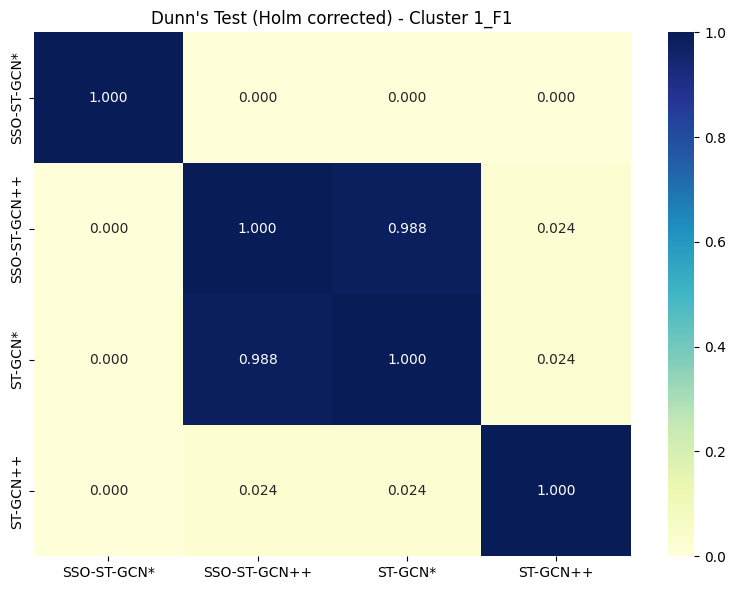

: 

In [ ]:
import scikit_posthocs as sp
import seaborn as sns
import matplotlib.pyplot as plt

# 重新命名欄位讓 Dunn’s test 能識別
dunn_df = cluster0_df.rename(columns={
    'model': 'group',
    'Cluster 1_F1': 'value'
})

# 執行 Dunn’s test 並進行 Bonferroni 校正
# dunn_result = sp.posthoc_dunn(dunn_df, val_col='value', group_col='group', p_adjust='bonferroni')
dunn_result = sp.posthoc_dunn(dunn_df, val_col='value', group_col='group', p_adjust='holm')
# 顯示結果
print("\n=== Dunn’s test with Bonferroni correction (Cluster 1_F1) ===")
print(dunn_result)

# （可選）畫出熱力圖
plt.figure(figsize=(8, 6))
sns.heatmap(dunn_result, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("Dunn's Test (Holm corrected) - Cluster 1_F1")
plt.tight_layout()
plt.show()
